_Técnicas de Aprendizaje Automático_

_Máster Universitario en Inteligencia Artificial_

# Caso Grupal: Clasificación de mensajes de odio

## Objetivos

Mediante este trabajo se pretende que el estudiante ponga en práctica la aplicación de un proceso completo de machine learning a la clasificación de mensajes de odio.

El objetivo es generar un proyecto completo de machine learning para clasificar mensajes de odio. Debe detallar los pasos que hay que realizar para la clasificación de mensajes, así como una evaluación de los resultados.

- Decidir la técnica de aprendizaje automático a utilizar
- Analizar diferentes modelos de aprendizaje supervisado para la clasificación de mensajes de odio.
- Evaluar los resultados obtenidos por cada modelo en términos de precisión, recall, y f1.

## Descripción de la actividad

La empresa SureTech Innovations quiere implementar un clasificador de mensajes de odio. Para ello se deben entrenar diferentes modelos de clasificación, evaluar el rendimiento de cada uno de ellos, y finalmente, decidir cuál sería el mejor.

Para llevar a cabo esta actividad cuentas con el dataset simplificado de HateSpeech en la siguiente URL: https://github.com/almudenaris/TAA/blob/main/out.csv

Los pasos que se deben seguir para desarrollar esta actividad son:

1.	¿Qué tarea de aprendizaje automático se pretende resolver? ¿Qué análisis previos serían necesarios realizar para saber si es posible construir el modelo que buscamos? Realiza un análisis exploratorio de datos adecuado a la tarea que se pretende resolver y al dataset facilitado. Explica con detalle, en base a la tarea que se quiere resolver, qué análisis serían necesarios realizar sobre los datos.

2.	En base a la tarea que se pide realizar y a las características del dataset decide qué algoritmo o algoritmos se deben utilizar. Implementa tres modelos. Realiza los entrenamientos necesarios para cada uno de ellos. Explica por qué son convenientes los algoritmos elegidos.

3.	Realiza una explicación de las métricas de evaluación que se deben utilizar para valorar la bondad del modelo. Justifica la decisión de las elegidas. ¿Cómo habría que evaluar el modelo? Evalúa los modelos entrenados en el punto anterior y explica los resultados obtenidos.


## Dataset

El dataset original proporcionado en el proyecto transversal ha sido adaptado para la realización de esta actividad. Esa adaptación ha incluido:

- Eliminación de nulos y duplicados
- Eliminación de URLs, emojis y menciones a los periódicos
- Eliminación de filas vacías
- Limpieza y homogeneización de datos.
    - Convertir la totalidad del texto a minúscula
    - Eliminar signos de puntuación
    - Eliminar números
    - Eliminar espacios en blanco adicionales
    - Eliminar palabras con longitud menor a 2 caracteres
    - Eliminar stopwords
    - Tokenización
    - Lematización
- Proceso de extracción de características
    - Conteo de palabras positivas (A)
    - Conteo de palabras negativas (B)
    - Conteo del número de bigrams más comunes (C)
    - Conteo del número de menciones a otros usuarios (D)
    - Categoría del sentimiento según librería ‘pysentimiento’ en español (E)

- Estandarización de las características (A_t,..E_t)
- Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

## EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./out.csv')

In [2]:
print(df.head())
print(df.info())
print(df.describe())

   A   B   C  D  E                                         comentario  label  \
0  2  64  30  0  2  pandemia,originado,covid,cierto,incidencia,aba...    0.0   
1  4  70  21  0  0  ser,mes,larga,espera,llegar,momento,siempre,pr...    0.0   
2  4  88  50  0  0  cartagena,san,sebastiar,fuengirola,irun,orense...    0.0   
3  3  38  21  0  0  pleno,dia,verano,calor,plan,mas,apetecibl,disf...    0.0   
4  0  59  17  0  0  pasado,junio,celebro,dia,luchar,frente,leishma...    0.0   

        A_t       B_t        C_t  ...    Valor_1    Valor_2   Valor_3  \
0  1.851102  2.759647   7.145831  ...   5.108388  13.227660 -0.771127   
1  3.990202  3.054765   4.877255  ...  12.189130  19.461233 -1.662227   
2  3.990202  3.940120  12.187108  ...  15.721875  48.629021 -1.662227   
3  2.920652  1.480801   4.877255  ...   4.324903  14.244765 -1.216677   
4 -0.287998  2.513715   3.869000  ...  -0.723945  -1.114264  0.119973   

    Valor_4    Valor_5   Valor_6   Valor_7   Valor_8   Valor_9  Valor_10  
0  0.

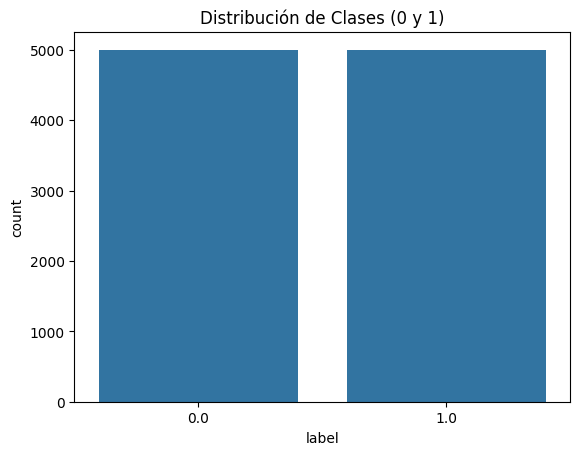

label
0.0    5000
1.0    5000
Name: count, dtype: int64


In [3]:
sns.countplot(x='label', data=df)
plt.title('Distribución de Clases (0 y 1)')
plt.show()
print(df['label'].value_counts())

El análisis inicial de los datos revela un conjunto de datos balanceado en cuanto a clases (odio y no odio), lo cual facilitará el modelado.

In [4]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def palabras_mas_frecuentes(df, clase, n=20):
    palabras = Counter()
    for mensaje in df[df['label'] == clase]['comentario']:
        for palabra in mensaje.split():
            if palabra not in stopwords.words('spanish'):
                palabras[palabra] += 1
    return palabras.most_common(n)

palabras_odio = palabras_mas_frecuentes(df, 1)  # Clase 1: Odio
palabras_no_odio = palabras_mas_frecuentes(df, 0)  # Clase 0: No odio

print("Palabras más frecuentes en mensajes de odio:", palabras_odio)
print("Palabras más frecuentes en mensajes sin odio:", palabras_no_odio)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Palabras más frecuentes en mensajes de odio: [('terrorismo,informativo,', 89), ('terrorista,informativo,', 37), ('hdlgp,', 21), ('sinverguenza,', 16), ('hijo,puto,', 15), ('gentuzar,', 12), ('payaso,', 11), ('basura,', 11), ('hijo,puta,', 10), ('tonto,', 10), ('miserable,', 10), ('asqueroso,', 9), ('puta,madre,', 8), ('sinverguenzar,', 8), ('panfleto,', 8), ('imbecil,', 8), ('verguenza,', 8), ('panfleto,asqueroso,reaccionario,vomitivo,', 7), ('idiota,', 7), ('vacunar,puta,madre,', 7)]
Palabras más frecuentes en mensajes sin odio: [('poder,seguir,babelia,facebook,twitter,apuntarte,aqui,recibir,newsletter,semanal,', 24), ('guardia,civil,evacuado,persona,afectado,nuevo,volcar,palma,canarias,entrar,erupcion,domingo,hora,local,montaña,rajado,zona,forestal,cabeza,vaco,paso,nivel,emergencia,pasado,semaforo,rojo,islir,hora,local,afectar,municipio,tazacortar,paso,fuencaliente,mazo,llano,aridane,uno,persona,total,ser,evacuar,vecino,zón,alcala,paraiso,iniciado,evacuacion,barrio,pasar,llano,aridan

Una vez hemos identificado la distribución de clases podemos observar cuales son aquellas palabras más frecuentes en cada uno de los conjuntos marcados como odio y no odio, esto nos ayuda a identificar patrones comunes al momento de realizar las evaluaciones y observar cuales palabras son más influyentes en los entrenamientos de nuestros modelos.

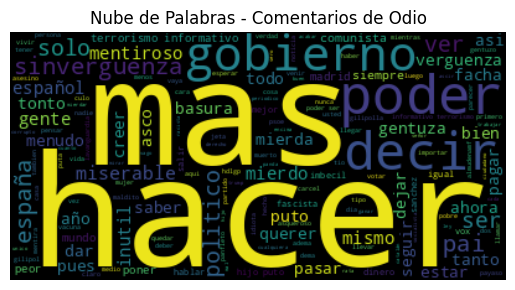

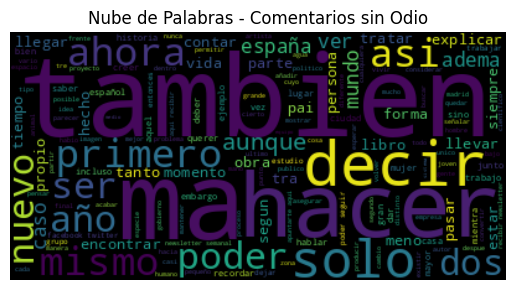

In [5]:
from wordcloud import WordCloud

text_odio = " ".join(df[df['label'] == 1]['comentario'])
wordcloud_odio = WordCloud().generate(text_odio)
plt.imshow(wordcloud_odio, interpolation='bilinear')
plt.axis("off")
plt.title('Nube de Palabras - Comentarios de Odio')
plt.show()


text_odio = " ".join(df[df['label'] == 0]['comentario'])
wordcloud_odio = WordCloud().generate(text_odio)
plt.imshow(wordcloud_odio, interpolation='bilinear')
plt.axis("off")
plt.title('Nube de Palabras - Comentarios sin Odio')
plt.show()

Se identificaron palabras clave distintivas asociadas al odio, como insultos y lenguaje despectivo, así como patrones léxicos más neutros en los mensajes sin odio. La visualización de nubes de palabras confirmaestas tendencias.

## SELECCIÓN Y ENTRENAMIENTO DE LOS MODELOS

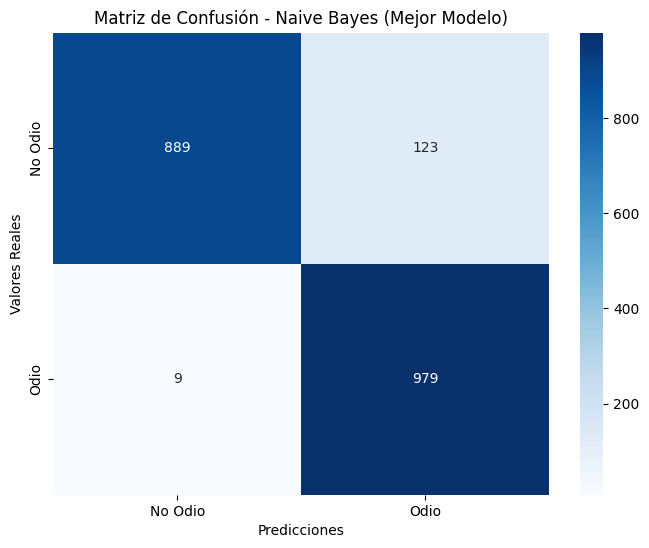


Reporte de clasificación:
              precision    recall  f1-score   support

         0.0       0.99      0.88      0.93      1012
         1.0       0.89      0.99      0.94       988

    accuracy                           0.93      2000
   macro avg       0.94      0.93      0.93      2000
weighted avg       0.94      0.93      0.93      2000

Mejores hiperparámetros: {'var_smoothing': 1e-09}


In [10]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd


X = df[['A_t', 'B_t', 'C_t', 'D_t', 'E_t', 'Valor_1', 'Valor_2',
        'Valor_3', 'Valor_4', 'Valor_5', 'Valor_6', 'Valor_7',
         'Valor_8', 'Valor_9', 'Valor_10']]
y = df['label']

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir el modelo Naive Bayes
model = GaussianNB()

# Definir el espacio de búsqueda de hiperparámetros
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]  # Valores comunes para var_smoothing
}

# Configurar Grid Search
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy')

# Ejecutar Grid Search
grid_search.fit(X_train, y_train)

# Evaluar el mejor modelo en el conjunto de prueba
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Métricas de evaluación
matriz_confusion_NB = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(matriz_confusion_NB, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Odio', 'Odio'], yticklabels=['No Odio', 'Odio'])
plt.title('Matriz de Confusión - Naive Bayes (Mejor Modelo)')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.show()

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# Mejores hiperparámetros
print("Mejores hiperparámetros:", grid_search.best_params_)

## EVALUACIÓN DE LOS MODELOS Y COMPARATIVA

In [ ]:
# coloca tu código y respuestas del punto 3 en esta sección